# Phenology Prediction Results Overview

Results across three temporal configurations:
- **4 months** (quarterly: Mar, Jun, Sep, Dec)
- **8 months** (growing season: Mar–Oct)
- **12 months** (all months)

In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import path_config
from lib.utils_plotting import (
    print_avg_results, results_file, get_mae,
    plot_methods_regions_split, plot_mae_improvement_by_region,
    plot_performance_tiles
)

sns.set_theme()

MONTH_SUBSETS = {
    4: [3, 6, 9, 12],
    8: [3, 4, 5, 6, 7, 8, 9, 10],
    12: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
}

METHODS_TABLE = [
    "random_baseline_1.0_test",
    "shallow_transformer_pixels_1.0_test",
    "prithvi_pretrained_multiscale_crops_conv3d_crop48_1.0_test",
    "ensemble_multiscale_crop48_shallow_transformer_test",
    "shallow_transformer_pixels_priorwork_data_test",
]

all_results = {}
all_results_w_regions = {}
all_results_val = {}
all_results_w_regions_val = {}
all_mae_dfs = {}

for n_months, months in MONTH_SUBSETS.items():
    print(f"Loading {n_months}-month subset...", end=" ")
    res_test, res_w_reg_test = results_file("test", selected_months=months)
    res_val, res_w_reg_val = results_file("val", selected_months=months)

    all_results[n_months] = res_test
    all_results_w_regions[n_months] = res_w_reg_test
    all_results_val[n_months] = res_val
    all_results_w_regions_val[n_months] = res_w_reg_val

    mae_dict = {"HLStile": [], "Date": [], "MAE": [], "Method": [], "SiteID": [], "years": []}
    ref_key = "shallow_transformer_pixels_1.0_test"
    for tile, siteid, year in res_w_reg_test[ref_key][["HLStile", "SiteID", "years"]].drop_duplicates().values:
        for key in res_w_reg_test.keys():
            mae_dict = get_mae(res_w_reg_test[key], tile, siteid, year, mae_dict, key)

    all_mae_dfs[n_months] = pd.DataFrame(mae_dict)
    print("done.")

print("All subsets loaded.")

## 1. Cross-Subset Comparison

How does performance change as more temporal data becomes available? We compare Prithvi Multiscale, the 1D Transformer, and their ensemble across 4, 8, and 12 input months. The prior work model (trained on its own data) serves as a fixed reference.

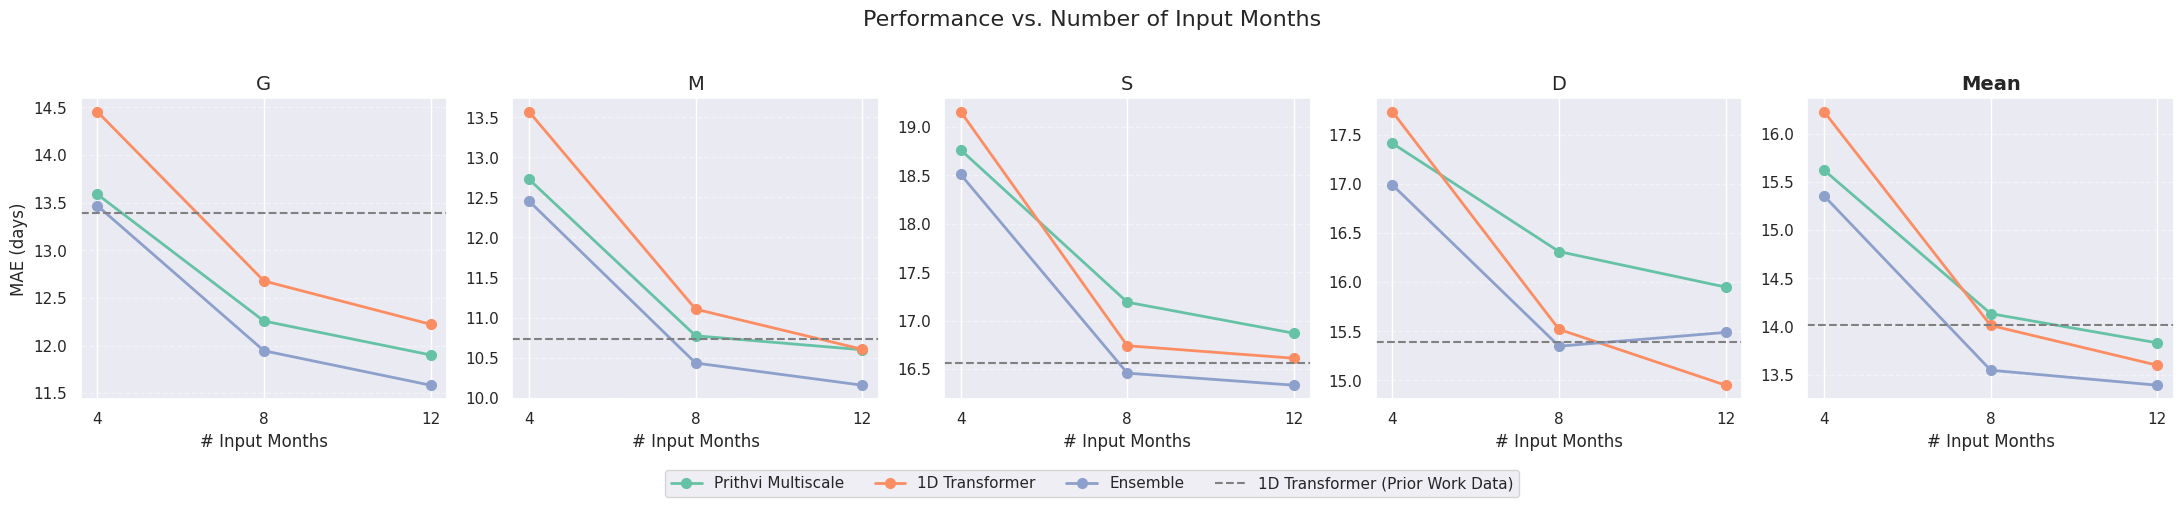

In [14]:
methods_compare = {
    "Prithvi Multiscale": "prithvi_pretrained_multiscale_crops_conv3d_crop48_1.0_test",
    "1D Transformer": "shallow_transformer_pixels_1.0_test",
    "Ensemble": "ensemble_multiscale_crop48_shallow_transformer_test",
}
prior_work_key = "shallow_transformer_pixels_priorwork_data_test"

dates = ["G", "M", "S", "D"]
n_months_list = sorted(MONTH_SUBSETS.keys())

# Build comparison dataframe
rows = []
for n_months in n_months_list:
    mdf = all_mae_dfs[n_months]
    for name, key in methods_compare.items():
        for d in dates:
            rows.append({"Months": n_months, "Method": name, "Date": d,
                         "MAE": mdf[(mdf["Method"] == key) & (mdf["Date"] == d)]["MAE"].mean()})
        rows.append({"Months": n_months, "Method": name, "Date": "Mean",
                     "MAE": mdf[mdf["Method"] == key]["MAE"].mean()})

comp_df = pd.DataFrame(rows)

# Prior work MAE (fixed reference)
prior_mae = {}
mdf_ref = all_mae_dfs[12]
for d in dates:
    prior_mae[d] = mdf_ref[(mdf_ref["Method"] == prior_work_key) & (mdf_ref["Date"] == d)]["MAE"].mean()
prior_mae["Mean"] = mdf_ref[mdf_ref["Method"] == prior_work_key]["MAE"].mean()

# Plot
fig, axes = plt.subplots(1, 5, figsize=(22, 4.5), sharey=False)
colors = sns.color_palette("Set2", len(methods_compare))

for idx, d in enumerate(dates + ["Mean"]):
    ax = axes[idx]
    for i, name in enumerate(methods_compare.keys()):
        sub = comp_df[(comp_df["Method"] == name) & (comp_df["Date"] == d)]
        ax.plot(sub["Months"], sub["MAE"], marker="o", label=name,
                color=colors[i], linewidth=2, markersize=7)
    ax.axhline(y=prior_mae[d], color="gray", linestyle="--",
               linewidth=1.5, label="1D Transformer (Prior Work Data)" if idx == 0 else None)

    ax.set_title(d, fontsize=14, fontweight="bold" if d == "Mean" else "normal")
    ax.set_xlabel("# Input Months")
    ax.set_xticks(n_months_list)
    if idx == 0:
        ax.set_ylabel("MAE (days)")
    ax.grid(axis="y", linestyle="--", alpha=0.4)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4,
           bbox_to_anchor=(0.5, -0.08), fontsize=11)
fig.suptitle("Performance vs. Number of Input Months", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [4]:
# Build multi-level summary table
all_methods = {**methods_compare, "Prior Work": prior_work_key}
table_rows = []
for name, key in all_methods.items():
    for n in n_months_list:
        mdf = all_mae_dfs[n]
        row = {"Method": name, "Months": f"{n}m"}
        for d in dates:
            row[d] = mdf[(mdf["Method"] == key) & (mdf["Date"] == d)]["MAE"].mean()
        row["Mean"] = mdf[mdf["Method"] == key]["MAE"].mean()
        table_rows.append(row)

summary_df = pd.DataFrame(table_rows).round(1).set_index(["Method", "Months"])
summary_df

G     M     S     D  Mean
Method             Months                              
Prithvi Multiscale 4m      13.6  12.7  18.8  17.4  15.6
                   8m      12.3  10.8  17.2  16.3  14.1
                   12m     11.9  10.6  16.9  15.9  13.8
1D Transformer     4m      14.5  13.6  19.2  17.7  16.2
                   8m      12.7  11.1  16.7  15.5  14.0
                   12m     12.2  10.6  16.6  15.0  13.6
Ensemble           4m      13.5  12.5  18.5  17.0  15.4
                   8m      11.9  10.4  16.5  15.3  13.5
                   12m     11.6  10.2  16.3  15.5  13.4
Prior Work         4m      13.4  10.7  16.6  15.4  14.0
                   8m       NaN   NaN   NaN   NaN   NaN
                   12m     13.4  10.7  16.6  15.4  14.0

## 2. Per-Subset Overview

Summary tables for each temporal configuration.

In [5]:
subset_names = {
    4: "4 Months (m3-6-9-12)",
    8: "8 Months (m3-4-5-6-7-8-9-10)",
    12: "12 Months (all)",
}

for n_months in sorted(MONTH_SUBSETS.keys()):
    print(f"\n{'='*70}")
    print(f" {subset_names[n_months]}")
    print(f"{'='*70}")
    print_avg_results(METHODS_TABLE, all_mae_dfs[n_months])


 4 Months (m3-6-9-12)
                                                               G     M     S     D  Mean
Method                                                                                  
random_baseline_1.0_test                                    38.5  35.6  37.7  37.5  37.3
shallow_transformer_pixels_1.0_test                         14.5  13.6  19.2  17.7  16.2
prithvi_pretrained_multiscale_crops_conv3d_crop48_1.0_test  13.6  12.7  18.8  17.4  15.6
ensemble_multiscale_crop48_shallow_transformer_test         13.5  12.5  18.5  17.0  15.4
shallow_transformer_pixels_priorwork_data_test              13.4  10.7  16.6  15.4  14.0

 8 Months (m3-4-5-6-7-8-9-10)
                                                               G     M     S     D  Mean
Method                                                                                  
random_baseline_1.0_test                                    38.2  35.4  37.9  37.4  37.2
shallow_transformer_pixels_1.0_test                     

## 3. Detailed Analysis

Configure `SELECTED_MONTHS` below to explore any subset in depth, then re-run all cells in this section.

In [6]:
# ============================================================
# Change this to analyze a different subset, then re-run below
SELECTED_MONTHS = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
# Options:
#   [3, 6, 9, 12]                            -- 4 months
#   [3, 4, 5, 6, 7, 8, 9, 10]                -- 8 months
#   [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]  -- 12 months
# ============================================================

n_sel = len(SELECTED_MONTHS)
mae_df = all_mae_dfs[n_sel]
sel_results = all_results[n_sel]
sel_results_w_regions = all_results_w_regions[n_sel]
sel_results_val = all_results_val[n_sel]
ensemble_key = "ensemble_multiscale_crop48_shallow_transformer_test"

print(f"Detailed analysis for {n_sel} months: {SELECTED_MONTHS}")

Detailed analysis for 12 months: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]


### 3a. Effect of Crop Size on Multiscale Model

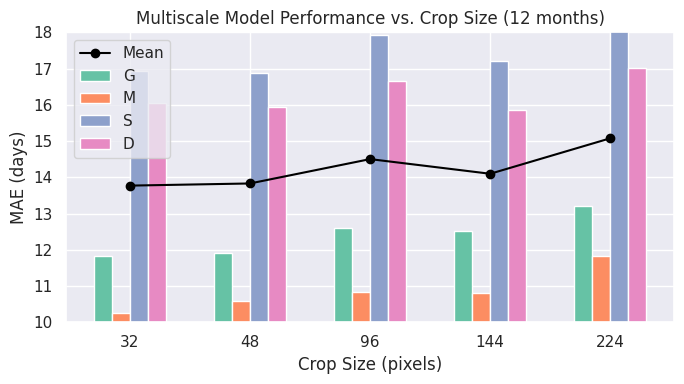

In [8]:
crop_methods = {
    32:  "prithvi_pretrained_multiscale_crops_conv3d_crop32_1.0_test",
    48:  "prithvi_pretrained_multiscale_crops_conv3d_crop48_1.0_test",
    96:  "prithvi_pretrained_multiscale_crops_conv3d_crop96_1.0_test",
    144: "prithvi_pretrained_multiscale_crops_conv3d_crop144_1.0_test",
    224: "prithvi_pretrained_multiscale_crops_conv3d_crop224_1.0_test",
}

crop_dates = ["G", "M", "S", "D"]
crop_sizes = sorted(crop_methods.keys())

mae_per_date = {d: [] for d in crop_dates}
mae_mean = []

for cs in crop_sizes:
    df_crop = mae_df[mae_df["Method"] == crop_methods[cs]]
    for d in crop_dates:
        mae_per_date[d].append(df_crop[df_crop["Date"] == d]["MAE"].mean())
    mae_mean.append(df_crop["MAE"].mean())

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(crop_sizes))
width = 0.15
colors_bar = sns.color_palette("Set2", 5)

for i, d in enumerate(crop_dates):
    ax.bar(x + i * width, mae_per_date[d], width, label=d, color=colors_bar[i])

ax.plot(x + 1.5 * width, mae_mean, marker="o", color="black",
        linewidth=1.5, label="Mean", zorder=5)
ax.set_xticks(x + 1.5 * width)
ax.set_xticklabels([str(cs) for cs in crop_sizes])
ax.set_xlabel("Crop Size (pixels)")
ax.set_ylabel("MAE (days)")
ax.set_title(f"Multiscale Model Performance vs. Crop Size ({n_sel} months)")
ax.set_ylim(10, 18)
ax.legend()
plt.tight_layout()
plt.show()

### 3b. Progressive Multi-Scale Ensemble

Starting from crop32 alone, progressively adding larger crop sizes into a convex ensemble.

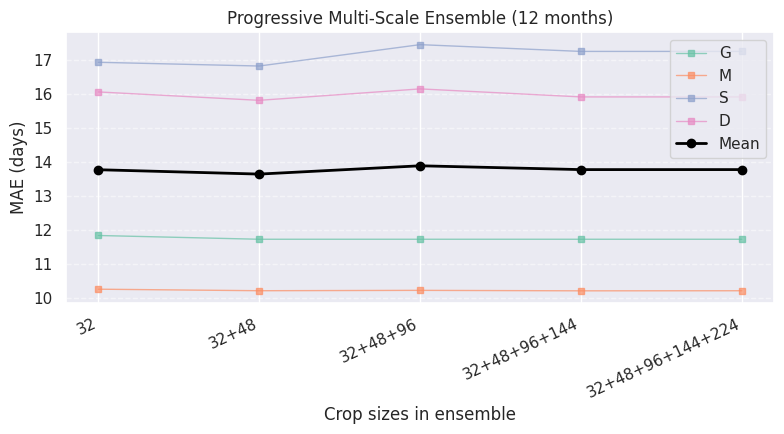


Crops                           G       M       S       D    Mean
------------------------------------------------------------
32                           11.8    10.3    16.9    16.1    13.8
32+48                        11.7    10.2    16.8    15.8    13.6
32+48+96                     11.7    10.2    17.4    16.1    13.9
32+48+96+144                 11.7    10.2    17.2    15.9    13.8
32+48+96+144+224             11.7    10.2    17.2    15.9    13.8


In [9]:
progressive_steps = [
    ("32",               "prithvi_pretrained_multiscale_crops_conv3d_crop32_1.0_test"),
    ("32+48",            "ensemble_multiscale_crop32_crop48_test"),
    ("32+48+96",         "ensemble_multiscale_crop32_crop48_crop96_test"),
    ("32+48+96+144",     "ensemble_multiscale_crop32_crop48_crop96_crop144_test"),
    ("32+48+96+144+224", "ensemble_multiscale_crop32_crop48_crop96_crop144_crop224_test"),
]

step_dates = ["G", "M", "S", "D"]
step_labels = []
step_mae_per_date = {d: [] for d in step_dates}
step_mae_mean = []

for label, key in progressive_steps:
    df_step = mae_df[mae_df["Method"] == key]
    step_labels.append(label)
    per_date = []
    for d in step_dates:
        mae_val = df_step[df_step["Date"] == d]["MAE"].mean()
        step_mae_per_date[d].append(mae_val)
        per_date.append(mae_val)
    step_mae_mean.append(np.mean(per_date))

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(step_labels))
colors_prog = sns.color_palette("Set2", 5)

for i, d in enumerate(step_dates):
    ax.plot(x, step_mae_per_date[d], marker="s", markersize=5, label=d,
            color=colors_prog[i], linewidth=1, alpha=0.7)

ax.plot(x, step_mae_mean, marker="o", color="black", linewidth=2,
        label="Mean", zorder=5)
ax.set_xticks(x)
ax.set_xticklabels(step_labels, rotation=25, ha="right")
ax.set_xlabel("Crop sizes in ensemble")
ax.set_ylabel("MAE (days)")
ax.set_title(f"Progressive Multi-Scale Ensemble ({n_sel} months)")
ax.legend(loc="upper right")
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

print(f"\n{'Crops':<25s}  {'G':>6s}  {'M':>6s}  {'S':>6s}  {'D':>6s}  {'Mean':>6s}")
print("-" * 60)
for i, label in enumerate(step_labels):
    vals = [step_mae_per_date[d][i] for d in step_dates]
    print(f"{label:<25s}  {vals[0]:6.1f}  {vals[1]:6.1f}  {vals[2]:6.1f}  {vals[3]:6.1f}  {step_mae_mean[i]:6.1f}")

### 3c. Eco-Region Analysis

Prithvi performs substantially better on the North American Deserts region. This improvement disappears without pretraining.

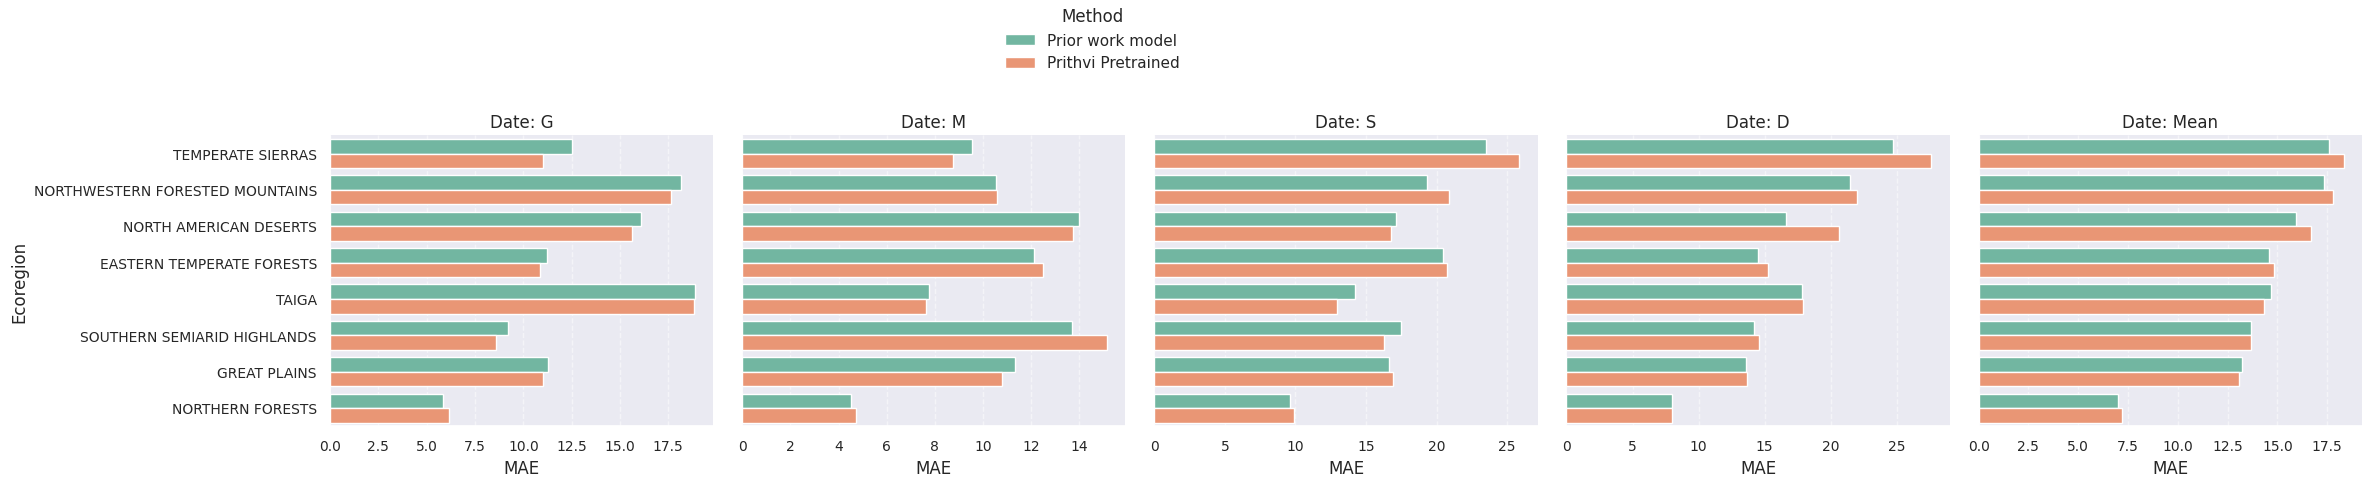

In [10]:
mae_df_eco = mae_df.copy()
mae_df_eco["Method"] = mae_df_eco["Method"].replace(
    "shallow_transformer_pixels_1.0_test", "Prior work model")
mae_df_eco["Method"] = mae_df_eco["Method"].replace(
    "prithvi_pretrained_multiscale_crops_conv3d_crop48_1.0_test", "Prithvi Pretrained")

plot_methods_regions_split(
    mae_df_eco,
    geo_path=path_config.get_data_geojson(),
    eco_path="useco1/NA_CEC_Eco_Level1.shp",
    methods=["Prior work model", "Prithvi Pretrained"],
)

### 3d. Ensemble Performance

The ensemble of Prithvi Multiscale and the 1D Transformer improves average performance, especially on North American Deserts.

In [11]:
methods_ensemble = [
    "shallow_transformer_pixels_1.0_test",
    "prithvi_pretrained_multiscale_crops_conv3d_crop48_1.0_test",
    ensemble_key,
    "shallow_transformer_pixels_priorwork_data_test",
]
print_avg_results(methods_ensemble, mae_df)

                                                               G     M     S     D  Mean
Method                                                                                  
shallow_transformer_pixels_1.0_test                         12.2  10.6  16.6  15.0  13.6
prithvi_pretrained_multiscale_crops_conv3d_crop48_1.0_test  11.9  10.6  16.9  15.9  13.8
ensemble_multiscale_crop48_shallow_transformer_test         11.6  10.2  16.3  15.5  13.4
shallow_transformer_pixels_priorwork_data_test              13.4  10.7  16.6  15.4  14.0


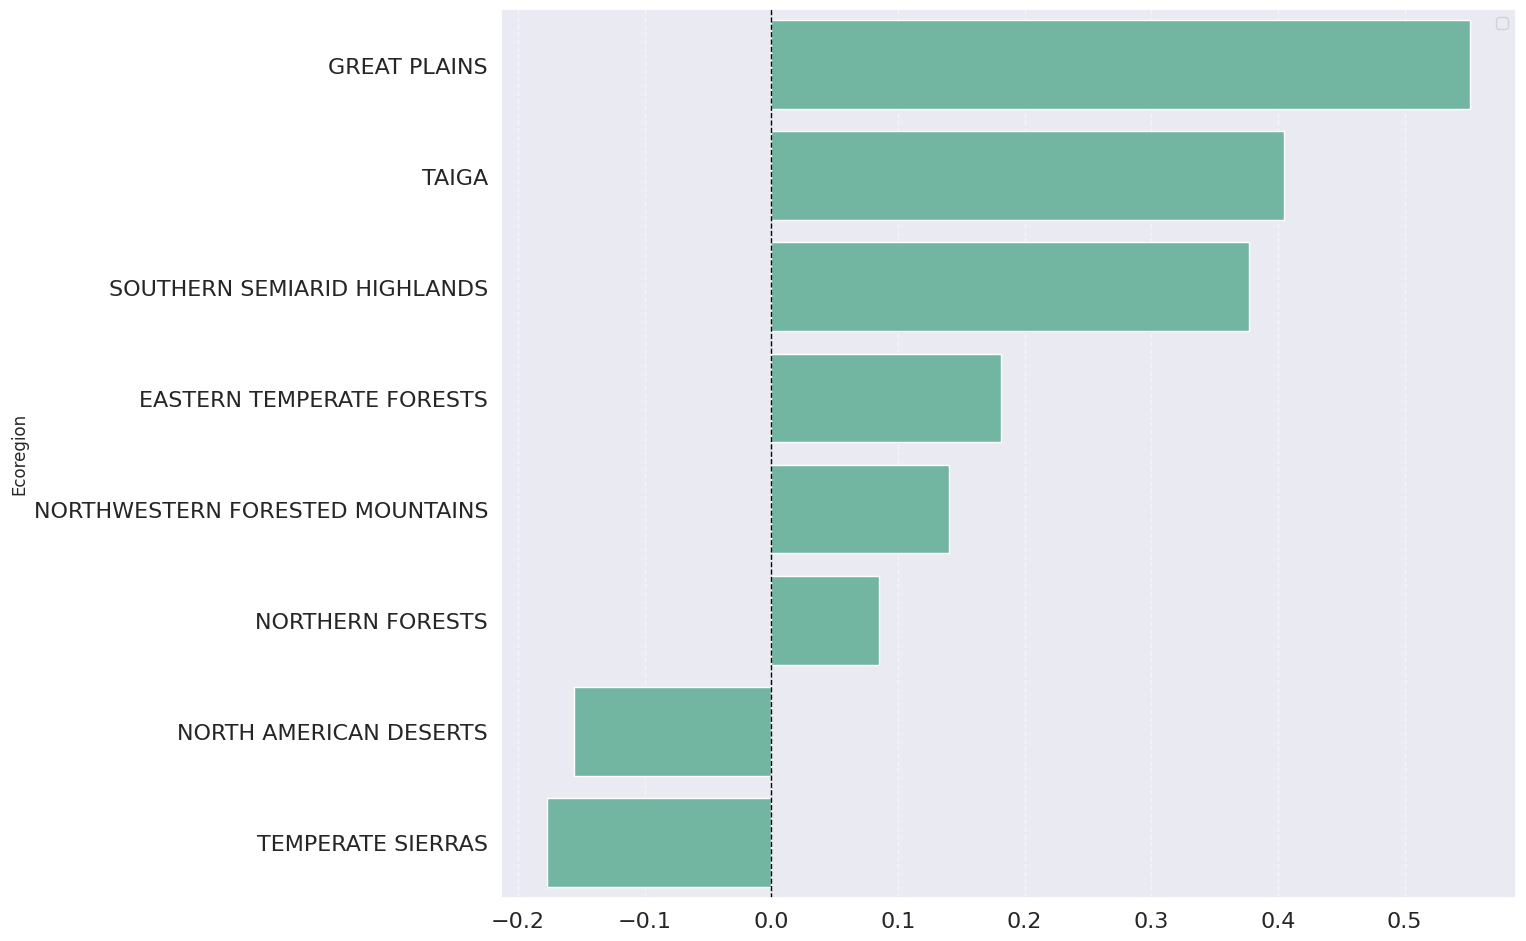

In [12]:
mae_df_imp = mae_df.copy()
plot_mae_improvement_by_region(
    mae_df_imp,
    geo_path=path_config.get_data_geojson(),
    eco_path="useco1/NA_CEC_Eco_Level1.shp",
    methods_to_compare=[ensemble_key],
    anchor_method="shallow_transformer_pixels_1.0_test",
    figsize=(14, 10),
)

### 3e. Per-Tile Performance

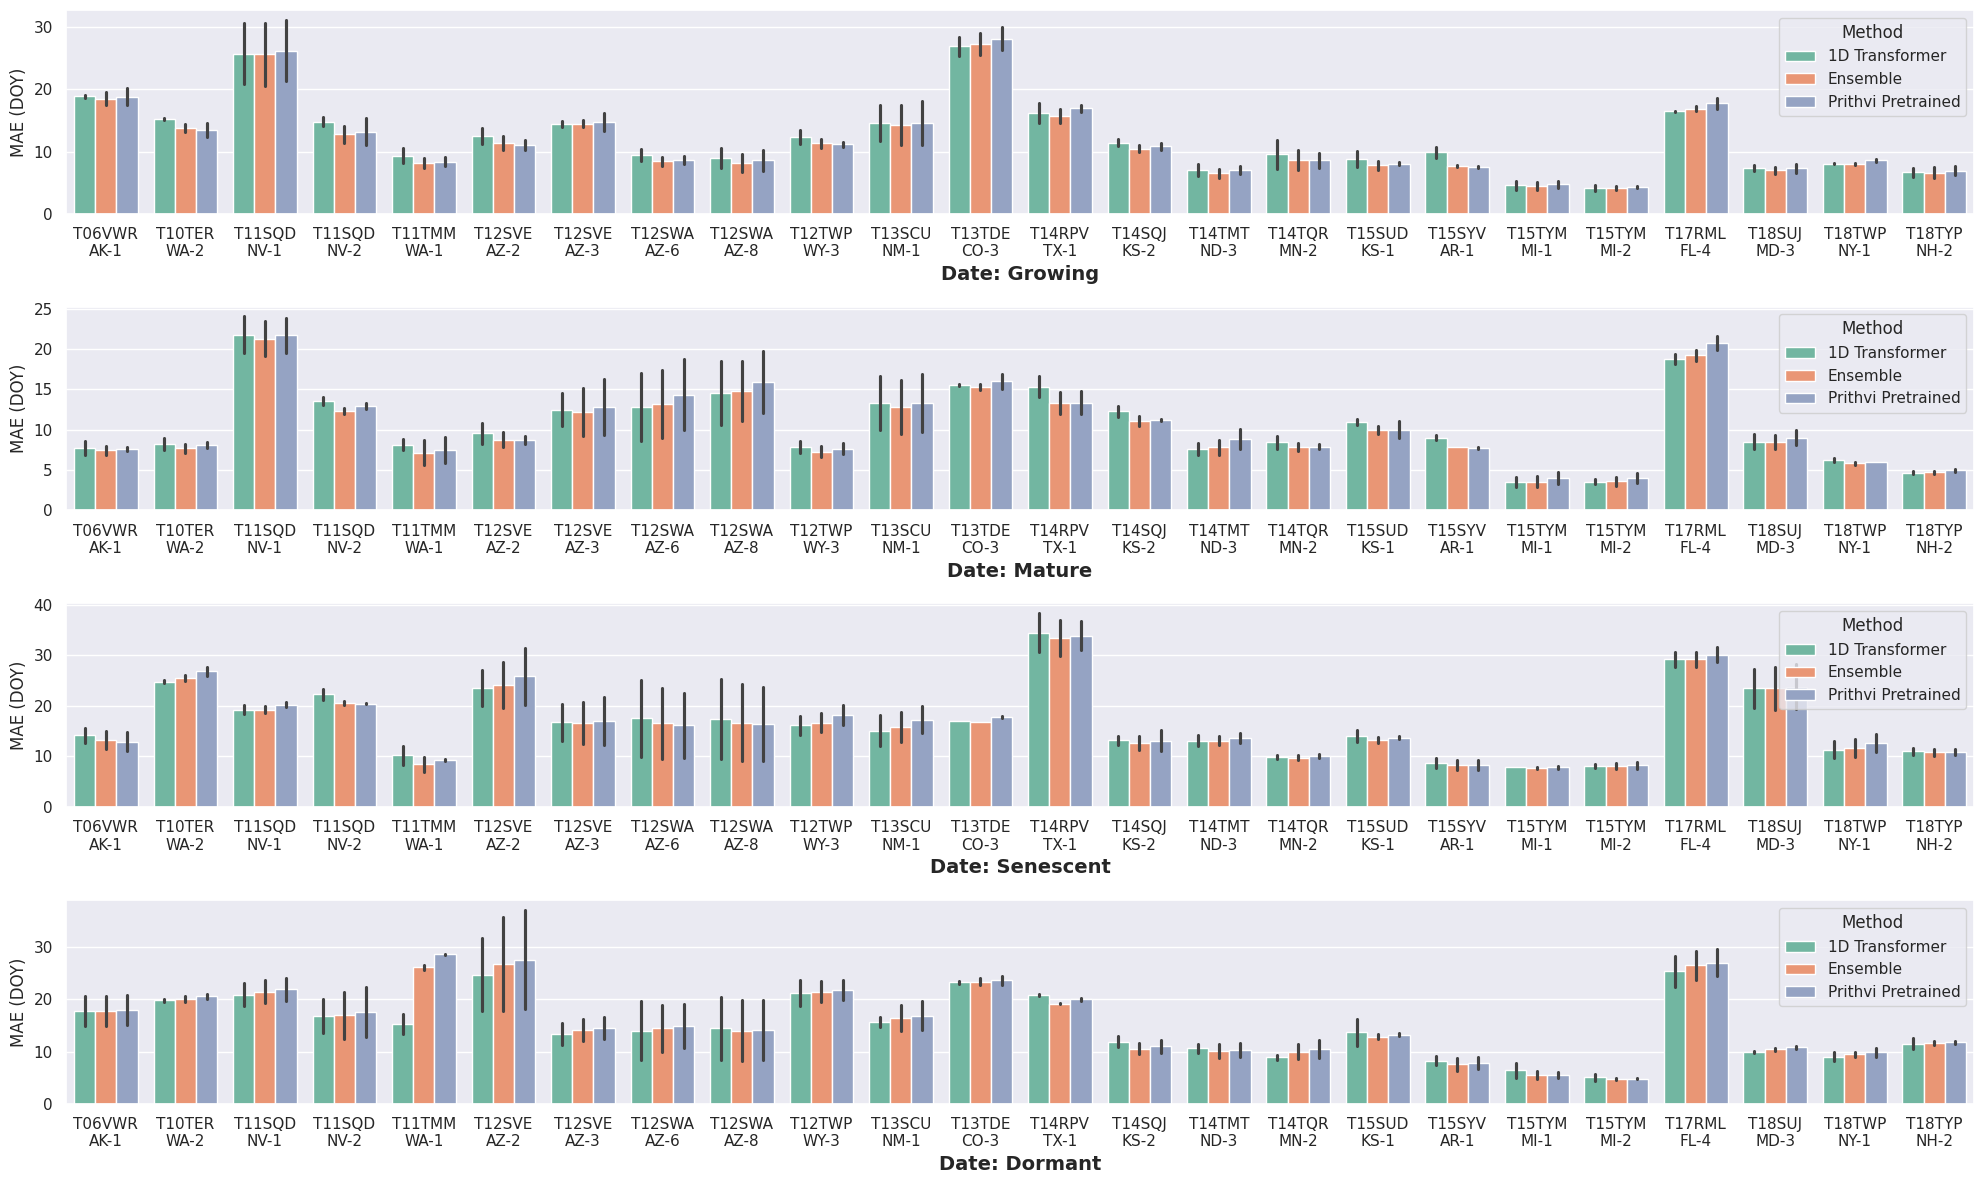

In [13]:
mae_df_tiles = mae_df.copy()
mae_df_tiles["Method"] = mae_df_tiles["Method"].replace(
    "shallow_transformer_pixels_1.0_test", "1D Transformer")
mae_df_tiles["Method"] = mae_df_tiles["Method"].replace(
    "prithvi_pretrained_multiscale_crops_conv3d_crop48_1.0_test", "Prithvi Pretrained")
mae_df_tiles["Method"] = mae_df_tiles["Method"].replace(
    ensemble_key, "Ensemble")

plot_performance_tiles(mae_df_tiles, methods=["1D Transformer",
                                              "Prithvi Pretrained",
                                              "Ensemble"])